In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df=pd.read_csv(r"C:\Users\anas\Downloads\wearables_monitoring_data.csv")

In [15]:
df.head(5)

,Unnamed: 0,X1,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
0,0,1,25,1,156.921647,74.872053,62.986954,68.135806,10.173303,0.092330,6.280164,6.281904,62.584922,-0.903196,7.511803,0.042224,1.282418,5.815576,apple watch,Lying
1,1,2,20,1,182.221336,68.475631,16.316123,56.208551,0.168211,0.025374,6.231803,5.714110,54.682353,0.236376,6.551301,0.029993,15.995793,0.414000,apple watch,Lying
2,2,3,32,1,179.784072,75.098988,1.000000,71.707234,15.310934,0.000440,6.134085,6.229458,54.693268,-1.000000,21.370364,0.135383,0.590429,0.000440,apple watch,Lying
3,3,4,31,0,158.224936,63.317797,687.052829,61.474449,2.279399,0.365399,5.931150,6.137201,62.336502,-1.000000,-10.166910,-0.011700,17.857847,251.048078,apple watch,Lying
4,4,5,23,1,177.145549,95.523413,101.474466,73.488328,11.770796,0.000440,6.243469,6.309696,56.299818,1.000000,14.208968,0.161462,4.113836,0.044649,apple watch,Lying


In [16]:
df=df.drop(columns=["Unnamed: 0"])

In [148]:
df.columns
df["total_steps"].describe()

count    4163.000000
mean       10.623956
std        25.156463
min         1.000000
25%         2.019781
50%         5.422780
75%         9.344082
max       191.604033
Name: total_steps, dtype: float64

In [22]:
fitbit_df=df[df['device'] == 'fitbit']


In [23]:
df = fitbit_df.rename(columns={
    'X1': 'user_id',
    'height': 'height_cm',
    'weight': 'weight_kg',
    'steps': 'total_steps',
    'hear_rate': 'heart_rate',
    'calories': 'calories_burned',
    'distance': 'distance_km',
    'entropy_heart': 'heart_rate_entropy',
    'entropy_setps': 'steps_entropy',
    'resting_heart': 'resting_heart_rate',
    'corr_heart_steps': 'heart_steps_corr',
    'norm_heart': 'normalized_heart_rate',
    'sd_norm_heart': 'sd_normalized_heart',
    'activity': 'activity_type'
})

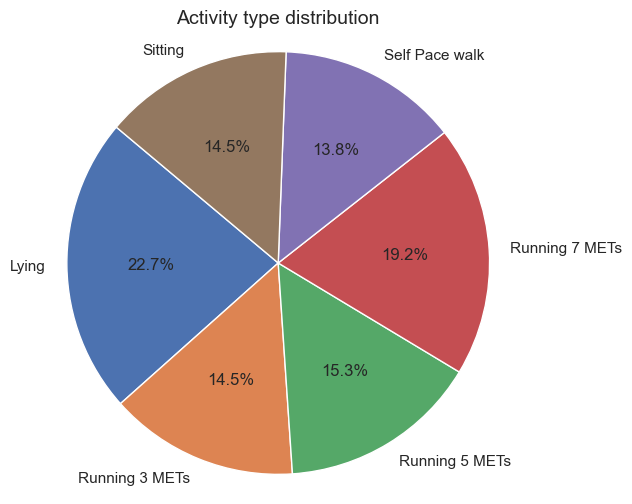

In [143]:
activity_counts = fitbit_df["activity_type"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(activity_counts,labels=activity_counts.index,autopct="%1.1f%%",startangle=140,)
plt.title("Activity type distribution", fontsize=14)
plt.axis("equal")
plt.savefig("pie unclean.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\anas\AppData\Local\Temp\ipykernel_3268\2422170590.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Activity Type", bbox_to_anchor=(1.05, 1), loc='upper left')


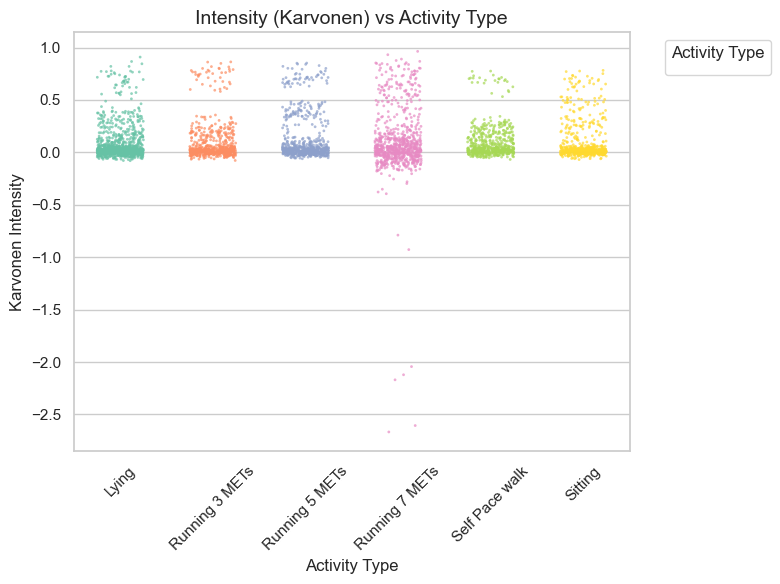

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.stripplot(
    data=fitbit_df,
    x="activity_type",
    y="intensity_karvonen",
    jitter=0.25,
    hue="activity_type",
    palette="Set2",
    alpha=0.7,
    size=2
)

plt.title("Intensity (Karvonen) vs Activity Type", fontsize=14)
plt.xlabel("Activity Type")
plt.ylabel("Karvonen Intensity")
plt.xticks(rotation=45)
plt.legend(title="Activity Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("Activity type unclean.png", dpi=300, bbox_inches="tight")
plt.show()


In [46]:
df_cl1= fitbit_df[
    (fitbit_df['activity_type'] == 'Lying') | 
    (fitbit_df['intensity_karvonen'] >= 0)
]

C:\Users\anas\AppData\Local\Temp\ipykernel_3268\16686676.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Activity Type", bbox_to_anchor=(1.05, 1), loc='upper left')


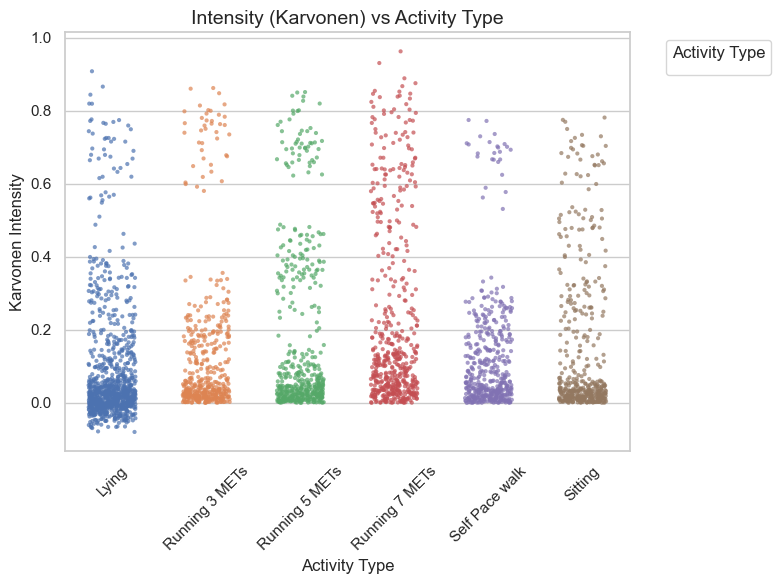

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.stripplot(
    data=df_cl1,
    x="activity_type",
    y="intensity_karvonen",
    jitter=0.25,
    hue="activity_type",
    alpha=0.7,
    size=3
)

plt.title("Intensity (Karvonen) vs Activity Type", fontsize=14)
plt.xlabel("Activity Type")
plt.ylabel("Karvonen Intensity")
plt.xticks(rotation=45)
plt.legend(title="Activity Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("Intensity vs activity unclean.png", dpi=300, bbox_inches="tight")
plt.show()


In [57]:
df_cl1['intensity_karvonen'].describe()


count    3295.000000
mean        0.143674
std         0.207365
min        -0.079559
25%         0.016124
50%         0.048044
75%         0.185050
max         0.963241
Name: intensity_karvonen, dtype: float64

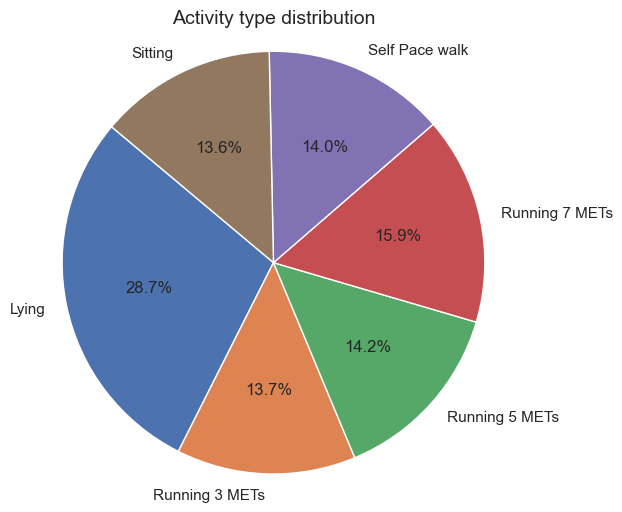

In [132]:
activity_counts_cl1 = df_cl1["activity_type"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(activity_counts_cl1,labels=activity_counts_cl1.index,autopct="%1.1f%%",startangle=140,)
plt.title("Activity type distribution", fontsize=14)
plt.axis("equal")
plt.savefig("Activity type clean.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\anas\AppData\Local\Temp\ipykernel_3268\433523740.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


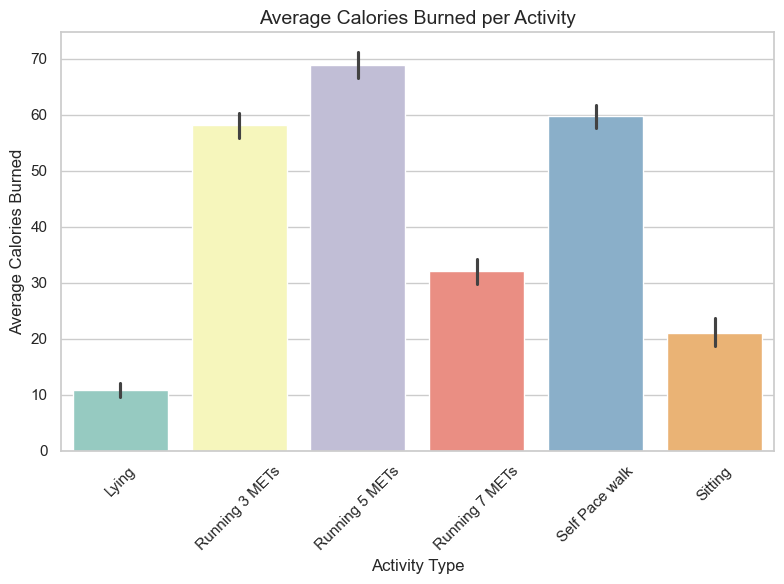

In [134]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=df_cl1,
    x="activity_type",
    y="calories_burned",
    estimator='mean',   # or np.median if you prefer median
    palette="Set3",         
)
plt.title("Average Calories Burned per Activity", fontsize=14)
plt.xlabel("Activity Type")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("calories per activity.png", dpi=300, bbox_inches="tight")
plt.show()


In [73]:
df_cl1.head()

,user_id,age,gender,height_cm,weight_kg,total_steps,heart_rate,calories_burned,distance_km,heart_rate_entropy,steps_entropy,resting_heart_rate,heart_steps_corr,normalized_heart_rate,intensity_karvonen,sd_normalized_heart,steps_times_distance,device,activity_type
5837,5838,25,0,162.165491,62.082246,1.973317,135.067561,0.056269,4.309977,0.057619,0.000000,147.756807,1.000000,4.813797,-0.035287,28.136708,8.504949,fitbit,Lying
5838,5839,36,0,169.428849,81.491577,15.797440,78.573190,0.056269,24.906795,6.218147,6.475733,88.445372,0.963304,-4.580700,0.020094,1.494843,393.463594,fitbit,Lying
5839,5840,36,0,160.897747,53.901347,6.208346,77.290658,2.492696,16.273632,6.185180,5.971094,83.318293,0.960847,-1.816418,0.021648,24.014774,101.032340,fitbit,Lying
5840,5841,46,0,161.956770,72.853457,1.000000,27.523802,4.827728,10.433110,0.093349,0.000000,42.476129,1.000000,-1.788192,-0.006035,66.561214,10.433110,fitbit,Lying
5841,5842,36,0,158.676422,55.176955,1.000000,76.242697,5.976989,22.855177,6.139285,6.403186,68.780773,0.978328,-3.605135,0.029463,26.654365,22.855177,fitbit,Lying


In [74]:
df_cl1['activity_type'].value_counts()


activity_type
Lying             945
Running 7 METs    524
Running 5 METs    467
Self Pace walk    460
Running 3 METs    452
Sitting           447
Name: count, dtype: int64

C:\Users\anas\AppData\Local\Temp\ipykernel_3268\1594639875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


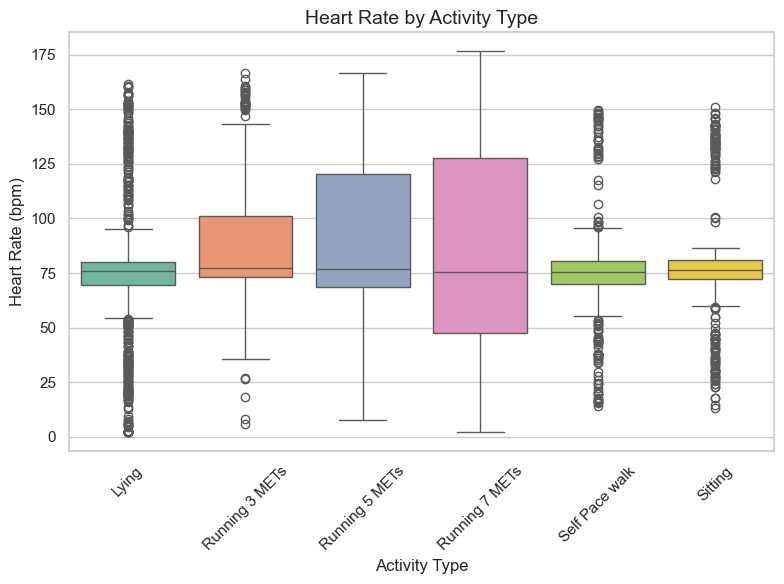

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_cl1,
    x="activity_type",
    y="heart_rate",
    palette="Set2"
)
plt.title("Heart Rate by Activity Type", fontsize=14)
plt.xlabel("Activity Type")
plt.ylabel("Heart Rate (bpm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("heart rate by activity.png", dpi=300, bbox_inches="tight")
plt.show()


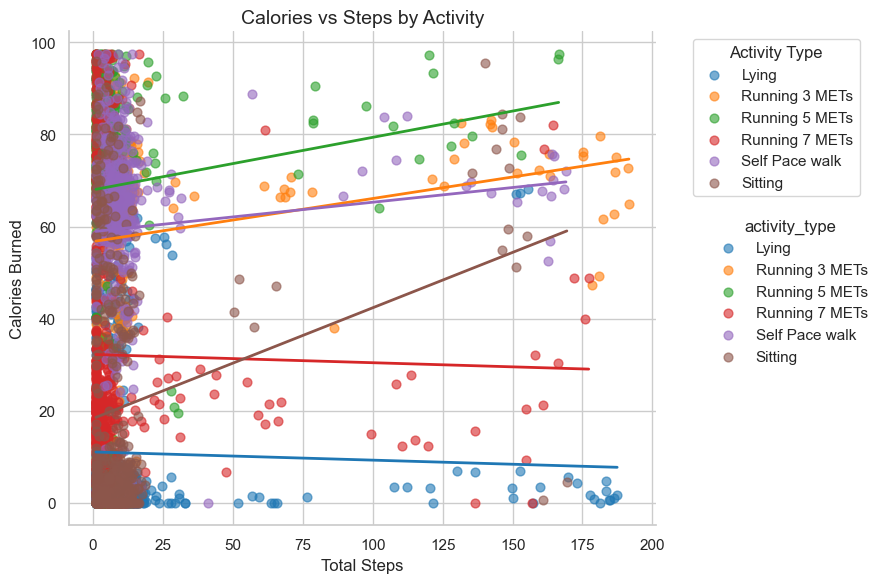

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

sns.lmplot(
    data=df_cl1,
    x="total_steps",
    y="calories_burned",
    hue="activity_type",
    palette="tab10",
    height=6,
    aspect=1.2,
    scatter_kws={"alpha":0.6, "s":40},
    line_kws={"linewidth":2},
    ci=None
)

plt.title("Calories vs Steps by Activity", fontsize=14)
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.legend(title="Activity Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Calories vs steps by activity.png", dpi=300, bbox_inches="tight")
plt.show()


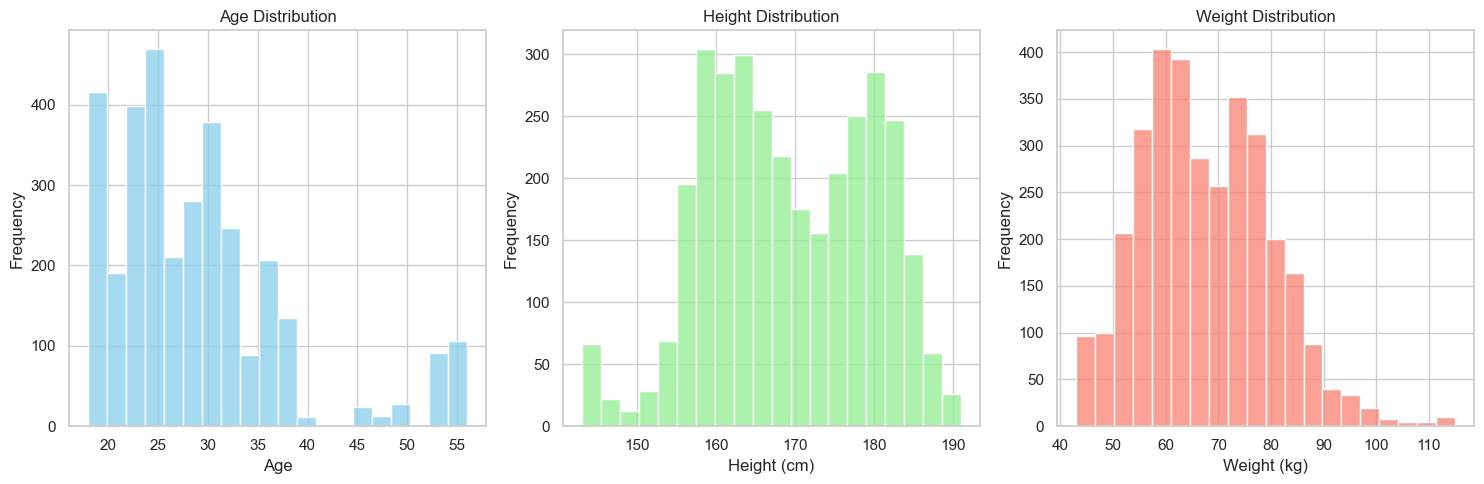

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=df_cl1, x="age", bins=20, color="skyblue", ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

sns.histplot(data=df_cl1, x="height_cm", bins=20, color="lightgreen", ax=axes[1])
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (cm)")
axes[1].set_ylabel("Frequency")

sns.histplot(data=df_cl1, x="weight_kg", bins=20, color="salmon", ax=axes[2])
axes[2].set_title("Weight Distribution")
axes[2].set_xlabel("Weight (kg)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("age height weight.png", dpi=300, bbox_inches="tight")
plt.show()


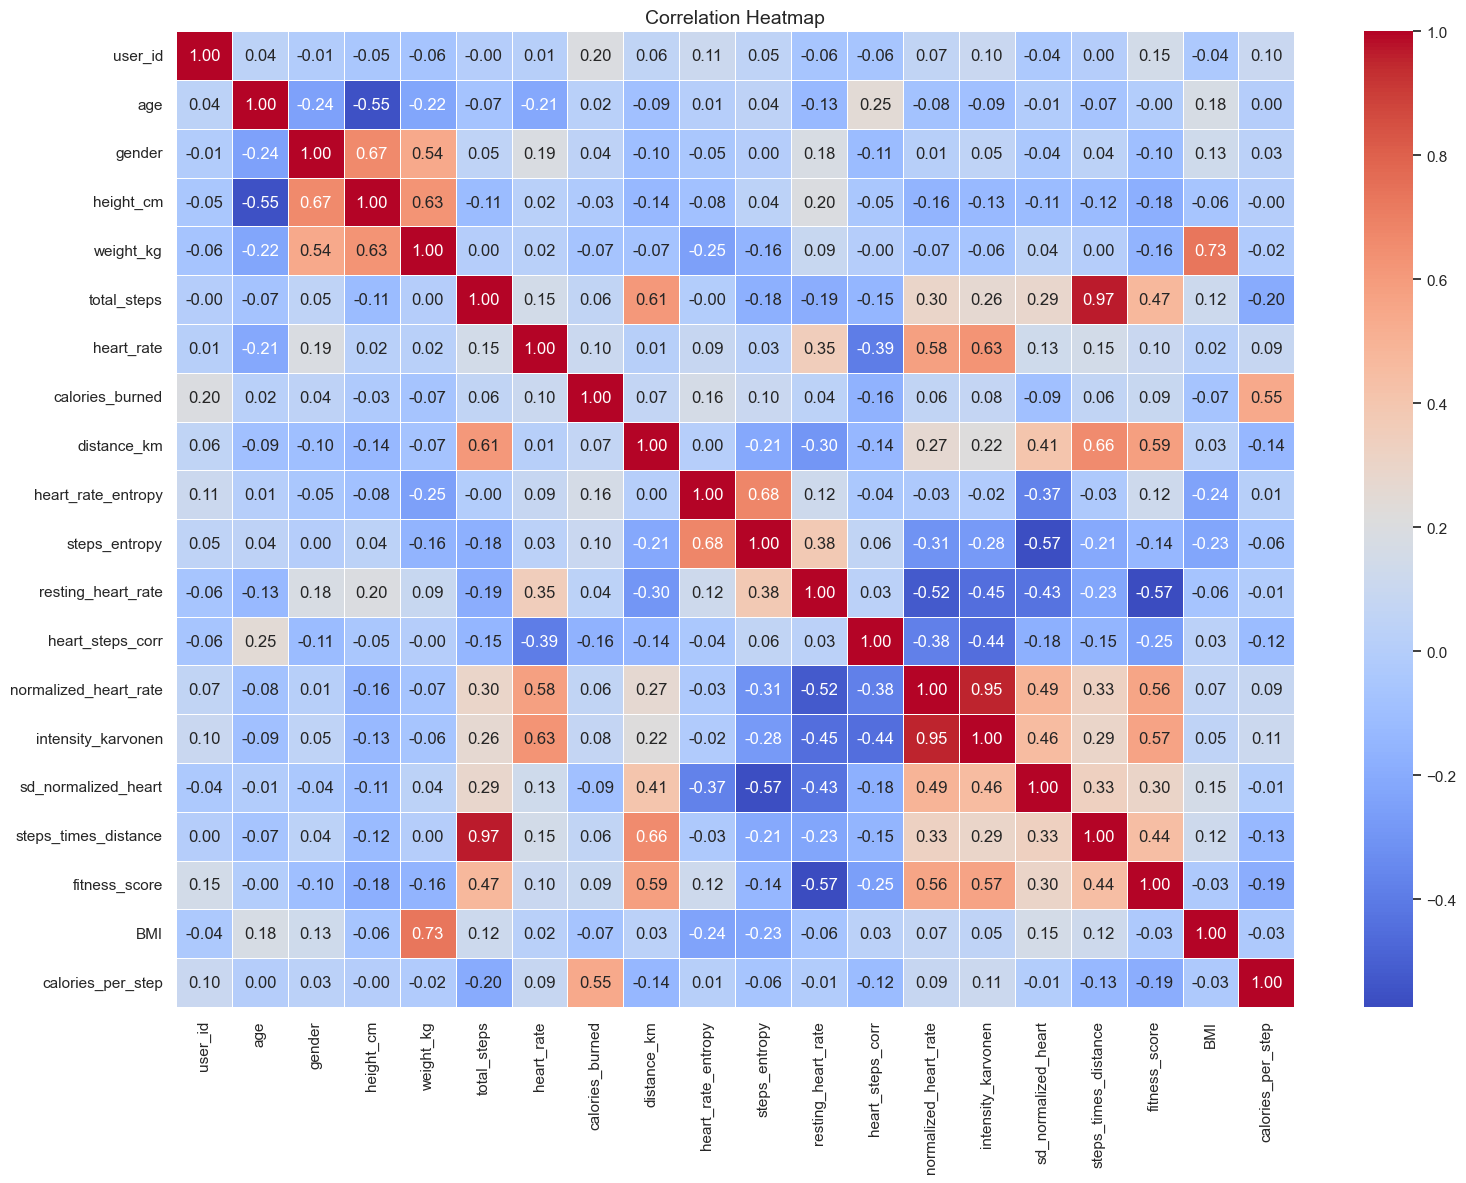

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(16,12))
sns.heatmap(
    df_cl1.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("corrheat.png", dpi=300, bbox_inches="tight")
plt.show()


In [117]:
df_cl1.columns

Index(['user_id', 'age', 'gender', 'height_cm', 'weight_kg', 'total_steps',
       'heart_rate', 'calories_burned', 'distance_km', 'heart_rate_entropy',
       'steps_entropy', 'resting_heart_rate', 'heart_steps_corr',
       'normalized_heart_rate', 'intensity_karvonen', 'sd_normalized_heart',
       'steps_times_distance', 'device', 'activity_type'],
      dtype='object')

In [122]:
df_cl1["BMI"] = df_cl1["weight_kg"] / (df_cl1["height_cm"] / 100) ** 2
df_cl1


,user_id,age,gender,height_cm,weight_kg,total_steps,heart_rate,calories_burned,distance_km,heart_rate_entropy,...,resting_heart_rate,heart_steps_corr,normalized_heart_rate,intensity_karvonen,sd_normalized_heart,steps_times_distance,device,activity_type,fitness_score,BMI
5837,5838,25,0,162.165491,62.082246,1.973317,135.067561,0.056269,4.309977,0.057619,...,147.756807,1.000000,4.813797,-0.035287,28.136708,8.504949,fitbit,Lying,-9.082993,23.607529
5838,5839,36,0,169.428849,81.491577,15.797440,78.573190,0.056269,24.906795,6.218147,...,88.445372,0.963304,-4.580700,0.020094,1.494843,393.463594,fitbit,Lying,-2.559125,28.388209
5839,5840,36,0,160.897747,53.901347,6.208346,77.290658,2.492696,16.273632,6.185180,...,83.318293,0.960847,-1.816418,0.021648,24.014774,101.032340,fitbit,Lying,-3.745122,20.820909
5840,5841,46,0,161.956770,72.853457,1.000000,27.523802,4.827728,10.433110,0.093349,...,42.476129,1.000000,-1.788192,-0.006035,66.561214,10.433110,fitbit,Lying,-2.014277,27.774864
5841,5842,36,0,158.676422,55.176955,1.000000,76.242697,5.976989,22.855177,6.139285,...,68.780773,0.978328,-3.605135,0.029463,26.654365,22.855177,fitbit,Lying,-2.954015,21.914569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,9994,56,1,167.490615,60.625976,8.646901,66.518118,0.056269,9.676956,6.111909,...,47.874625,0.920199,37.375807,0.320725,1.132267,83.675681,fitbit,Sitting,-1.478901,21.611146
9996,9997,49,0,155.418109,46.823447,1.000000,17.648130,0.056269,0.000440,6.217267,...,13.400051,0.529808,-3.146829,0.013658,40.196585,0.000440,fitbit,Sitting,-0.754648,19.384747
9997,9998,29,0,159.802347,60.031324,1.000000,30.140164,5.344197,0.000440,6.172561,...,21.800448,1.000000,8.529367,0.012315,1.877799,0.000440,fitbit,Sitting,-1.297146,23.507780
9998,9999,22,0,163.878165,57.726429,1.000000,142.105868,0.056269,0.105760,4.462252,...,3.000000,-0.003373,137.397941,0.694696,55.352995,0.105760,fitbit,Sitting,0.195039,21.494755


C:\Users\anas\AppData\Local\Temp\ipykernel_3268\2465297049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


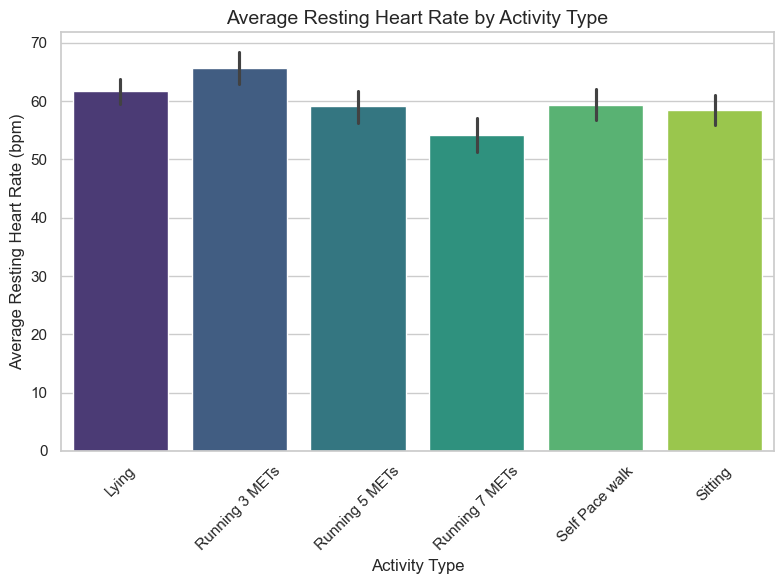

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.barplot(
    data=df_cl1,
    x="activity_type",
    y="resting_heart_rate",
    estimator="mean",
    palette="viridis"
)

plt.title("Average Resting Heart Rate by Activity Type", fontsize=14)
plt.xlabel("Activity Type")
plt.ylabel("Average Resting Heart Rate (bpm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("resting hr by activity.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\anas\AppData\Local\Temp\ipykernel_3268\263466684.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=activity_efficiency, x="activity_type", y="calories_per_step", palette="flare")


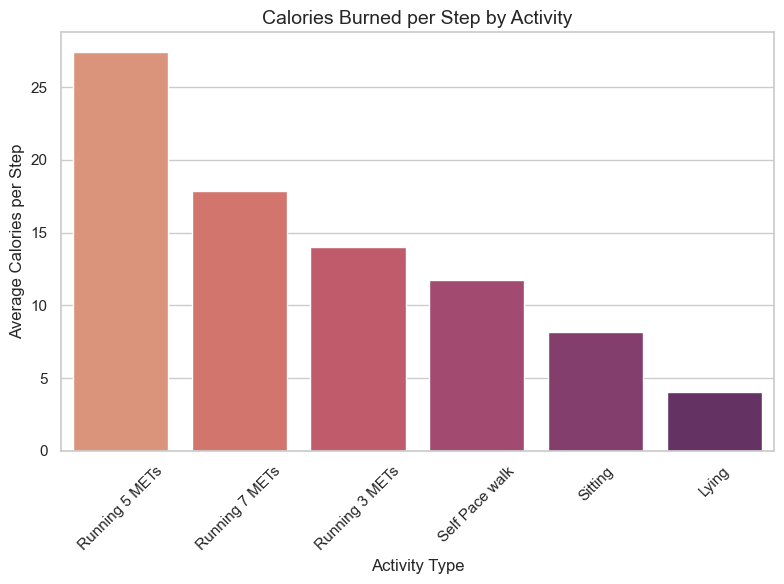

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

df_cl1["calories_per_step"] = df_cl1["calories_burned"] / df_cl1["total_steps"].replace(0, None)

activity_efficiency = (
    df_cl1.groupby("activity_type")["calories_per_step"]
    .mean()
    .reset_index()
    .sort_values("calories_per_step", ascending=False)
)

plt.figure(figsize=(8,6))
sns.barplot(data=activity_efficiency, x="activity_type", y="calories_per_step", palette="flare")
plt.title("Calories Burned per Step by Activity", fontsize=14)
plt.xlabel("Activity Type")
plt.ylabel("Average Calories per Step")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("calories_per_step.png", dpi=300, bbox_inches="tight")
plt.show()


In [142]:
df_cl1.head()

,user_id,age,gender,height_cm,weight_kg,total_steps,heart_rate,calories_burned,distance_km,heart_rate_entropy,...,heart_steps_corr,normalized_heart_rate,intensity_karvonen,sd_normalized_heart,steps_times_distance,device,activity_type,fitness_score,BMI,calories_per_step
5837,5838,25,0,162.165491,62.082246,1.973317,135.067561,0.056269,4.309977,0.057619,...,1.000000,4.813797,-0.035287,28.136708,8.504949,fitbit,Lying,0.088134,23.607529,0.028515
5838,5839,36,0,169.428849,81.491577,15.797440,78.573190,0.056269,24.906795,6.218147,...,0.963304,-4.580700,0.020094,1.494843,393.463594,fitbit,Lying,0.483278,28.388209,0.003562
5839,5840,36,0,160.897747,53.901347,6.208346,77.290658,2.492696,16.273632,6.185180,...,0.960847,-1.816418,0.021648,24.014774,101.032340,fitbit,Lying,0.388953,20.820909,0.401507
5840,5841,46,0,161.956770,72.853457,1.000000,27.523802,4.827728,10.433110,0.093349,...,1.000000,-1.788192,-0.006035,66.561214,10.433110,fitbit,Lying,0.254568,27.774864,4.827728
5841,5842,36,0,158.676422,55.176955,1.000000,76.242697,5.976989,22.855177,6.139285,...,0.978328,-3.605135,0.029463,26.654365,22.855177,fitbit,Lying,0.392352,21.914569,5.976989


In [146]:
df_cl1["total_steps"].describe()

count    3295.000000
mean       11.646308
std        27.281130
min         1.000000
25%         2.079358
50%         5.637753
75%         9.697267
max       191.604033
Name: total_steps, dtype: float64